Experiment 1 — FFT Low-Pass Filtering as a Frequency-Domain Optimizer on Synthetic Time-Series Data
======

Hypothesis
----------
Overfitted models learn not only the true underlying signal but also the
high-frequency noise components present in training data. If those spurious
high-frequency components can be identified and removed in the Fourier domain,
the resulting output should generalize better to unseen data — even without
any gradient-based retraining. This notebook provides the first proof-of-concept
test of this idea on a controlled synthetic time-series.

Setup
-----
- **Signal construction:** A composite synthetic time-series is built from four
  deterministic base components plus broadband Gaussian noise, all with a lag-1
  dependency (y[i] = f(x[i−1])):
  - x1: sinusoidal (f = 0.005 Hz, amplitude 210) + slow cosine (f = 0.001 Hz)
  - x2: square wave (f = 0.001 Hz, amplitude 19)
  - x3: sawtooth wave (f = 0.0055 Hz, amplitude 100)
  - x4: triangular wave (f = 0.0025 Hz, amplitude 22)
  - x5: Gaussian noise (μ=1, σ=5) acting as a DC offset with stochastic jitter
  - An additional per-segment Gaussian noise layer (σ=30) is added to simulate
    measurement noise, and the base signal is replicated and reversed across 4
    segments to create a long, stationary-looking but internally structured series.
- **Train / Test split:** The signal is split at the midpoint — the first half
  serves as the "training" signal and the second half as the held-out test signal.
- **Baseline ("DNN"):** A model that perfectly memorizes the training signal is
  simulated by using the raw training signal directly as a predictor for the
  test signal. This represents the worst-case of a model that has overfit to
  every noise sample in training.
- **Optimizer:** The FFT of the training signal is computed; a low-pass filter
  (LPF) with a frequency threshold is applied to zero out all spectral components
  above the cutoff; the IFFT reconstructs a denoised version of the training
  signal which is then used as the test-set prediction.
- **Threshold sweep:** The LPF cutoff is swept across [0, 1] in steps of 0.001
  to find the threshold that maximises R² on the test set, revealing the
  empirical relationship between spectral filtering aggressiveness and
  generalization quality.
- Random seed: 42 (NumPy).

Findings
--------
Applying a Fourier low-pass filter to the "memorized" training signal
substantially improves test-set prediction quality across all metrics:

| Metric             | Baseline (DNN / memorized) | FFT Optimizer (LPF filtered) | Improvement |
|--------------------|---------------------------|------------------------------|-------------|
| RMSE               | 42.41                     | 31.11                        | −11.30      |
| MAE                | 33.85                     | 24.79                        | −9.06       |
| R²                 | 0.9289                    | 0.9617                       | +0.0328     |
| MedAE              | 28.67                     | 20.95                        | −7.72       |
| Explained Variance | 0.9289                    | 0.9617                       | +0.0328     |
| Max Error          | 194.46                    | 146.65                       | −47.81      |

The threshold sweep confirms that an optimal LPF cutoff exists: filtering too
little leaves noise in the signal, while filtering too aggressively removes true
signal components and degrades performance. The best cutoff sits just above the
highest true signal frequency (~0.005–0.013 Hz), capturing all four deterministic
components while suppressing the broadband Gaussian noise.

This validates the core hypothesis: high-frequency components in a memorized
(overfit) signal are largely noise, and their removal via spectral filtering
yields a representation that generalises better to held-out data.

Next Steps
----------
- **Experiment 2:** Test the FFT optimizer on a wider class of synthetic signals
  and validate that the threshold sweep consistently recovers a cutoff near the
  true signal bandwidth.
- Explore whether the LPF threshold can be set automatically (e.g., via spectral
  energy concentration) rather than requiring an exhaustive sweep.
- Investigate the method on signals with non-stationary frequency content, where
  a global LPF may be insufficient.
- Extend to neural-network activations directly: apply FFT not to the output
  signal but to the intermediate layer activations of an overfit DNN, and study
  whether the same spectral noise pattern is present there.
- Develop a theoretical basis for *why* memorization deposits energy specifically
  in high-frequency spectral components.

In [3]:
# ----------------------------------------------------------------------------
# 1. Imports
# ----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# ----------------------------------------------------------------------------
# 2. Time axis and global random seed
# ----------------------------------------------------------------------------
# 'domain' sets the total time span; 'step' is the sampling interval (dt=0.1
# gives a Nyquist frequency of 5 Hz, well above all signal components below).
domain = 8000
step   = 0.1
t      = np.arange(0, domain, step)

np.random.seed(42)

In [73]:
# ----------------------------------------------------------------------------
# 3. Define the four deterministic signal components + noise
# ----------------------------------------------------------------------------
# Each component has a known frequency and amplitude. All true signal energy
# sits below ~0.006 Hz, which is the target passband for the LPF later.
#   x1 : sinusoid  (f=0.005 Hz, A=210) + slow cosine (f=0.001 Hz, A=12)
#   x2 : square wave         (f=0.001 Hz, A=19)
#   x3 : sawtooth wave       (f=0.0055 Hz, A=100)
#   x4 : triangular wave     (f=0.0025 Hz, A=22)
#   x5 : Gaussian noise      (mu=1, sigma=5) — stochastic DC-offset / drift
NOISE_F = 30   # per-segment additive noise standard deviation added later

# Amplitudes (kept as named constants for readability)
x1c = 210
x2c = 19
x3c = 100
x4c = 22

x1 = 210 * np.sin(2 * 3.14 * 0.005 * t) + 12 * np.cos(2 * 3.14 * 0.001 * t)
x2 = 19  * np.sign(np.sin(2 * np.pi * 0.001 * t))
x3 = 100 * (t * 0.0055 - np.floor(0.5 + t * 0.0055))
x4 = 22  * np.arcsin(np.sin(2 * np.pi * 0.0025 * t)) / np.pi
x5 = np.random.normal(1, 5, size=t.shape)   # broadband stochastic DC offset

In [75]:
# ----------------------------------------------------------------------------
# 4. Construct the label signal with a lag-1 dependency
# ----------------------------------------------------------------------------
# The target y[i] is defined as the SUM of all feature components at the
# PREVIOUS time step (y[i] = x1[i-1] + x2[i-1] + ... + x5[i-1]).
# This lag-1 structure means a model must learn a one-step-ahead prediction
# task — a simple but realistic formulation for time-series regression.
def generate_signal(t):
    y = np.zeros_like(t)

    # Lag-1: each output depends on the previous time step's features
    y[1:] = x1[:-1] + x2[:-1] + x3[:-1] + x4[:-1] + x5[:-1]

    # Initialise the first sample using the t=0 feature values (no predecessor)
    y[0] = x1[0] + x2[0] + x3[0] + x4[0] + x5[0]

    return y

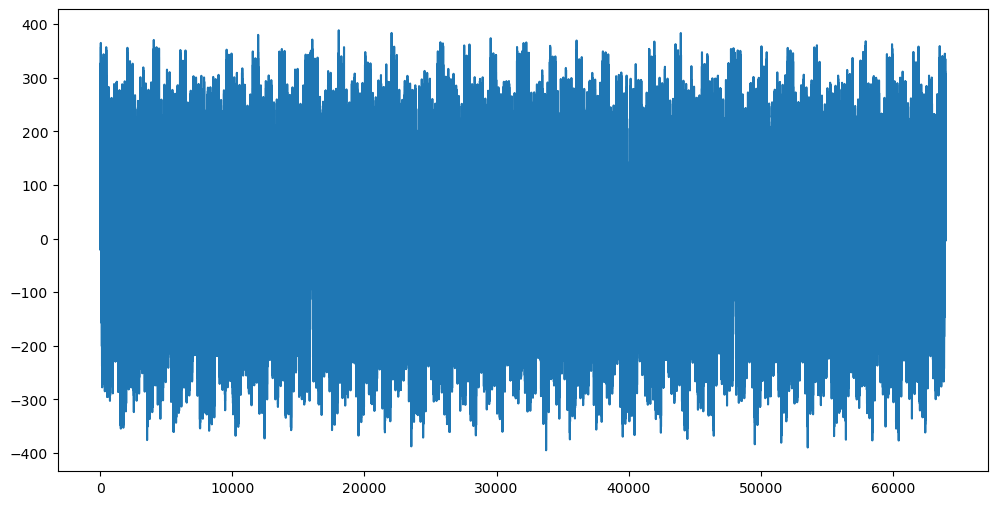

In [77]:
# ----------------------------------------------------------------------------
# 5. Build a long, noisy composite signal via replication
# ----------------------------------------------------------------------------
# The base signal and its time-reverse are concatenated to form one period,
# then four independent noisy copies of that period are stacked to create a
# long quasi-stationary series. The per-segment noise (sigma=NOISE_F=30)
# simulates measurement / observation noise layered on top of the true signal.
base_signal     = generate_signal(t)
inv_base_signal = np.flip(base_signal)           # time-reversed copy

time              = np.arange(0, 8 * domain, step)
intermediate_signal = np.concatenate((base_signal, inv_base_signal))

# Four independent noisy realisations of the base+reversed period
segment1 = intermediate_signal + np.random.normal(0, NOISE_F, size=intermediate_signal.shape)
segment2 = intermediate_signal + np.random.normal(0, NOISE_F, size=intermediate_signal.shape)
segment3 = intermediate_signal + np.random.normal(0, NOISE_F, size=intermediate_signal.shape)
segment4 = intermediate_signal + np.random.normal(0, NOISE_F, size=intermediate_signal.shape)

signal = np.concatenate((segment1, segment2, segment3, segment4))

# Visualise the full composite signal
plt.figure(figsize=(12, 6))
plt.plot(time, signal)

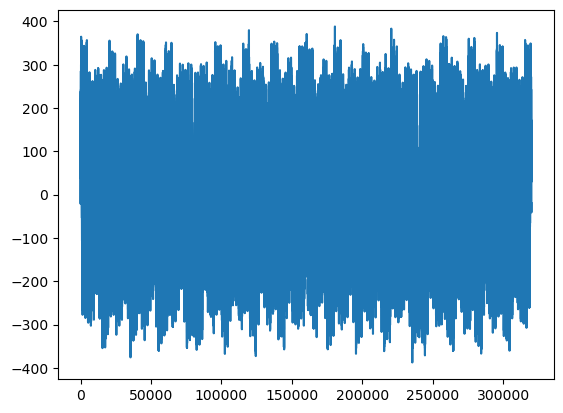

In [79]:
# ----------------------------------------------------------------------------
# 6. Train / test split
# ----------------------------------------------------------------------------
# The signal is split at its midpoint. The first half (signal_train) stands in
# for what a perfectly memorising DNN would have learned; the second half
# (signal_test) is the held-out evaluation window.
split_point  = len(signal) // 2
signal_train = signal[:split_point]
signal_test  = signal[split_point:]

plt.plot(signal_train)

[-16990.61041474 +6180.81591794j -19459.88284157 +5929.61059687j
 -10418.93532493+12164.29697878j ...   4986.73908597-10222.40785193j
 -19523.73120699 -2159.29357467j   5388.30010155-12222.10433763j]


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(-0.02, 0.02)

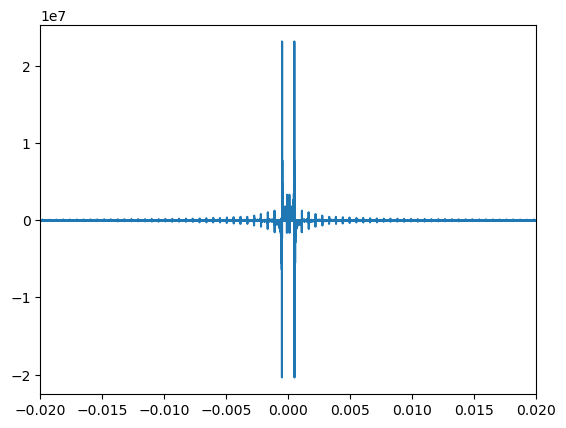

In [81]:
# ----------------------------------------------------------------------------
# 7. FFT of the training signal — spectral inspection
# ----------------------------------------------------------------------------
# Compute the discrete Fourier transform of signal_train. Plotting the
# two-sided spectrum around zero frequency allows us to visually confirm
# that true signal energy is concentrated in a narrow low-frequency band
# while noise energy is spread broadly across all frequencies.
Y_fft  = np.fft.fft(signal_train)
freqs  = np.fft.fftfreq(len(signal_train), 1)   # frequency axis (cycles / sample)

# Restrict to non-negative frequencies for inspection only
pos_mask   = freqs >= 0
Y_fft_pos  = Y_fft[pos_mask]
freqs_pos  = freqs[pos_mask]

# Print any spectral components above 0.06 Hz (should be noise only)
print(Y_fft_pos[freqs_pos > 0.06])

# Two-sided spectrum plot zoomed in to the signal band
plt.plot(freqs, Y_fft)
plt.xlim(-0.02, 0.02)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


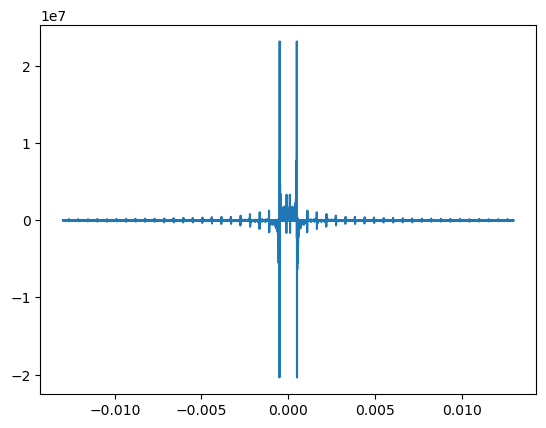

In [95]:
# ----------------------------------------------------------------------------
# 8. Apply a hard low-pass filter (LPF) in the frequency domain
# ----------------------------------------------------------------------------
# Zero out all spectral coefficients whose absolute frequency exceeds the
# threshold. This removes the broadband noise while leaving the true signal
# components (all below ~0.006 Hz) intact.
# threshold=0.013 is used here for illustration; the sweep in the final cell
# will find the empirically optimal cutoff.
threshold  = 0.013
lpf_mask   = np.abs(freqs) < threshold   # boolean mask: True = keep, False = zero
Y_fft_lpf  = Y_fft * lpf_mask            # apply mask in frequency domain
freqs_lpf  = freqs * lpf_mask

# Visualise the filtered spectrum
plt.plot(freqs_lpf, Y_fft_lpf)

In [97]:
# ----------------------------------------------------------------------------
# 9. Reconstruct the denoised signal via inverse FFT
# ----------------------------------------------------------------------------
# IFFT maps the filtered spectrum back to the time domain.
# Taking the real part discards negligible numerical imaginary residuals.
y_time_domain = np.fft.ifft(Y_fft_lpf).real

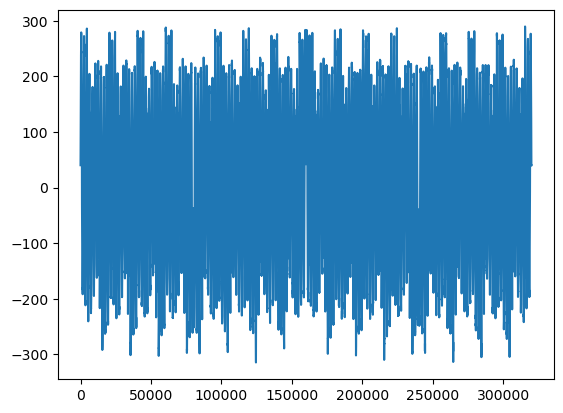

In [99]:
# ----------------------------------------------------------------------------
# 10. Visualise the reconstructed (denoised) signal
# ----------------------------------------------------------------------------
plt.plot(y_time_domain)

In [101]:
# ----------------------------------------------------------------------------
# 11. Evaluation utilities — multi-metric regression comparison
# ----------------------------------------------------------------------------
# regression_comparison_table() prints a side-by-side table of standard
# regression metrics for two predictors:
#   y_dnn : the raw training signal (proxy for a perfectly memorising DNN)
#   y_opt : the FFT low-pass filtered reconstruction (the Optimizer)
# Both are evaluated against y_true = signal_test (the held-out second half).
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              median_absolute_error, explained_variance_score,
                              max_error)

def regression_comparison_table(y_true, y_dnn, y_opt):

    def compute_metrics(y_true, y_pred):
        return {
            "RMSE":              np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE":               mean_absolute_error(y_true, y_pred),
            "R2":                r2_score(y_true, y_pred),
            "MedAE":             median_absolute_error(y_true, y_pred),
            "ExplainedVariance": explained_variance_score(y_true, y_pred),
            "MaxError":          max_error(y_true, y_pred),
        }

    dnn_metrics = compute_metrics(y_true, y_dnn)
    opt_metrics = compute_metrics(y_true, y_opt)

    print("\nRegression Model Comparison\n")
    header = f"{'Metric':<20}{'DNN':>15}{'Optimizer':>15}"
    print(header)
    print("-" * len(header))
    for key in dnn_metrics:
        print(f"{key:<20}{dnn_metrics[key]:>15.6f}{opt_metrics[key]:>15.6f}",
              "             ", np.abs(dnn_metrics[key] - opt_metrics[key]))

    return dnn_metrics, opt_metrics

In [103]:
# ----------------------------------------------------------------------------
# 12. Run the comparison: memorised signal vs. FFT-filtered Optimizer
# ----------------------------------------------------------------------------
# signal_train acts as the "DNN" prediction — what a model that perfectly
# memorised training data would output on the (same-length) test window.
# y_time_domain is the LPF-reconstructed prediction from step 9.
model_comparator = regression_comparison_table(signal_test, signal_train, y_time_domain)


Regression Model Comparison

Metric                          DNN      Optimizer
--------------------------------------------------
RMSE                      42.409493      31.111800               11.297693287124506
MAE                       33.854033      24.794310               9.05972305178338
R2                         0.928873       0.961721               0.03284803626371324
MedAE                     28.672973      20.950003               7.72297010513563
ExplainedVariance          0.928873       0.961721               0.03284803626371324
MaxError                 194.458598     146.645297               47.81330041711567


0.013000000000000001
0.961721335974356


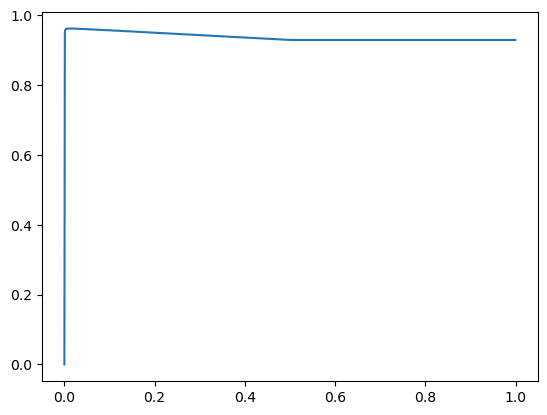

In [105]:
# ----------------------------------------------------------------------------
# 13. Threshold sweep — find the optimal LPF cutoff via R² on the test set
# ----------------------------------------------------------------------------
# Sweep the LPF cutoff frequency from 0 to 1 in steps of 0.001.
# For each threshold, apply the LPF, reconstruct the signal, and record R².
# The resulting curve reveals the trade-off: too low a cutoff removes true
# signal components; too high leaves noise in. The peak R² identifies the
# empirically optimal passband boundary.
r2_scores     = []
max_score     = 0
best_threshold = 0

for threshold in np.arange(0, 1, 0.001):
    lpf_mask      = np.abs(freqs) < threshold
    Y_fft_lpf     = Y_fft * lpf_mask
    y_time_domain = np.fft.ifft(Y_fft_lpf).real
    r_score       = r2_score(signal_test, y_time_domain)
    r2_scores.append(r_score)
    if r_score > max_score:
        max_score      = r_score
        best_threshold = threshold

print(f"Best threshold : {best_threshold:.3f}")
print(f"Best R²        : {max_score:.6f}")

# Plot R² vs. LPF cutoff frequency — the peak marks the optimal threshold
plt.xlabel("LPF cutoff frequency")
plt.ylabel("R² (test set)")
plt.title("Threshold Sweep: R² vs. Low-Pass Filter Cutoff")
plt.plot(np.arange(0, 1, 0.001), r2_scores)